# DeepAlgPro data exploration by split

This notebook keeps DeepAlgPro `train` and `test` separate at every step. Each split is parsed from FASTA into a tabular dataset with `sequence_id`, `sequence`, and `label`, checked for duplicates and class conflicts, filtered against the curated split CSVs produced in notebook `01`, downsampled within the split, visualized, and saved to its own cleaned CSV.

In [1]:
import os
from pathlib import Path

MPLCONFIGDIR = Path.cwd().resolve() / ".matplotlib"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing a data/ directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
SPLIT_FASTA_PATHS = {
    "train": DATA_DIR / "deepalgpro_all.train.fasta",
    "test": DATA_DIR / "deepalgpro_all.test.fasta",
}
SPLIT_OUTPUT_PATHS = {
    "train": DATA_DIR / "deepalgpro_train_cleaned.csv",
    "test": DATA_DIR / "deepalgpro_test_cleaned.csv",
}
OVERLAP_PATHS = {
    "positives_splitA": DATA_DIR / "positives_splitA.csv",
    "positives_splitB": DATA_DIR / "positives_splitB.csv",
    "negatives_splitA": DATA_DIR / "negatives_splitA.csv",
    "negatives_splitB": DATA_DIR / "negatives_splitB.csv",
}

for split_name, fasta_path in SPLIT_FASTA_PATHS.items():
    if not fasta_path.exists():
        raise FileNotFoundError(f"Missing {split_name} FASTA file: {fasta_path}")

for source_name, overlap_path in OVERLAP_PATHS.items():
    if not overlap_path.exists():
        raise FileNotFoundError(f"Missing overlap reference for {source_name}: {overlap_path}")

print(f"Project root: {PROJECT_ROOT}")
print("Split FASTA files:")
for split_name, fasta_path in SPLIT_FASTA_PATHS.items():
    print(f"  - {split_name}: {fasta_path.name}")


Project root: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0
Split FASTA files:
  - train: deepalgpro_all.train.fasta
  - test: deepalgpro_all.test.fasta


In [2]:
def parse_fasta(fasta_path: Path) -> list[dict]:
    records = []
    sequence_id = None
    sequence_lines = []

    with fasta_path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if sequence_id is not None:
                    sequence = "".join(sequence_lines)
                    records.append(
                        {
                            "sequence_id": sequence_id,
                            "sequence": sequence,
                            "label": 1 if sequence_id.startswith("allergen_") else 0,
                        }
                    )
                sequence_id = line[1:]
                sequence_lines = []
            else:
                sequence_lines.append(line)

    if sequence_id is not None:
        sequence = "".join(sequence_lines)
        records.append(
            {
                "sequence_id": sequence_id,
                "sequence": sequence,
                "label": 1 if sequence_id.startswith("allergen_") else 0,
            }
        )

    return records


split_dfs = {
    split_name: pd.DataFrame(parse_fasta(fasta_path)).reset_index(drop=True)
    for split_name, fasta_path in SPLIT_FASTA_PATHS.items()
}

for split_name, split_df in split_dfs.items():
    print(f"{split_name} preview")
    display(split_df.head())


train preview


,sequence_id,sequence,label
0,non-allergen_3154,MAAHTILASAPSHTTFSLISPFSSTPTNALSSSLQSSSFNGLSFKL...,0
1,non-allergen_2914,MAQFLRLCIWLLALGSCLLATVQADCSQDCAKCSYRLVRPGDINFL...,0
2,non-allergen_19622,MSSTTQAPEPVYQWTADEAVQFLKEWNFSLGIILLFITIILQFGYT...,0
3,allergen_2182,MSWQAYVDDHLMCEIEGTNNHLTAAAILGVDGSVWAQSANFPQFKP...,1
4,non-allergen_40251,MNLFVYIAQNPTLTKWFFCCVCTILTMPFFKKPYRKRGISRTPYEW...,0


test preview


,sequence_id,sequence,label
0,allergen_2145,MVKNLPPSVREQCIESQIVIRDCEEKKYGENCAELIKQCVTITGAP...,1
1,allergen_109,MKFFAVLALCIVGAIASPLTADEASLVQSSWKAVSHNEVEILAAVF...,1
2,allergen_2419,MSKARVYTDVNVLRPKEYWDYEALTVQWGEQDDYEVVRKVGRGKYS...,1
3,allergen_12,MAKLVLSLCFLLFSGCCFAFSFREQPQQNECQIQRLNALKPDNRIE...,1
4,allergen_117,MKIVLAIASLLALSAVYARPSSIKTFEEYKKAFNKSYATFEDEEAA...,1


In [3]:
for split_name, split_df in split_dfs.items():
    lengths = split_df["sequence"].str.len()
    class_counts = split_df["label"].value_counts().sort_index()
    duplicate_sequences = split_df[split_df.duplicated(subset=["sequence"], keep=False)]["sequence"].nunique()
    cross_class_sequences = (
        split_df.groupby("sequence")["label"]
        .nunique()
        .loc[lambda s: s > 1]
    )

    print(f"=== {split_name.upper()} ===")
    print(f"Total sequences: {len(split_df):,}")
    print("Class balance:")
    print(class_counts.rename(index={0: "non-allergenic", 1: "allergenic"}).to_string())
    print("Sequence length summary:")
    print(f"  min = {lengths.min()}")
    print(f"  max = {lengths.max()}")
    print(f"  mean = {lengths.mean():.2f}")
    print(f"Duplicate sequences: {int(duplicate_sequences):,}")
    print(f"Sequences appearing in both classes: {len(cross_class_sequences):,}")
    print()


=== TRAIN ===
Total sequences: 5,680
Class balance:
label
non-allergenic    2840
allergenic        2840
Sequence length summary:
  min = 11
  max = 999
  mean = 312.05
Duplicate sequences: 0
Sequences appearing in both classes: 0

=== TEST ===
Total sequences: 1,420
Class balance:
label
non-allergenic    710
allergenic        710
Sequence length summary:
  min = 11
  max = 979
  mean = 321.43
Duplicate sequences: 0
Sequences appearing in both classes: 0



In [4]:
shared_sequences = set(split_dfs["train"]["sequence"]) & set(split_dfs["test"]["sequence"])
print(f"Exact sequence overlap between train and test: {len(shared_sequences):,}")

if shared_sequences:
    train_overlap_rows = split_dfs["train"].loc[split_dfs["train"]["sequence"].isin(shared_sequences), ["sequence_id", "label", "sequence"]]
    test_overlap_rows = split_dfs["test"].loc[split_dfs["test"]["sequence"].isin(shared_sequences), ["sequence_id", "label", "sequence"]]
    print("Train examples with overlap:")
    display(train_overlap_rows.head(10))
    print("Test examples with overlap:")
    display(test_overlap_rows.head(10))


Exact sequence overlap between train and test: 0


In [5]:
overlap_sequences_by_source = {}
for source_name, overlap_path in OVERLAP_PATHS.items():
    overlap_df = pd.read_csv(overlap_path)
    if "sequence" not in overlap_df.columns:
        raise KeyError(f"{overlap_path} does not contain a 'sequence' column.")
    overlap_sequences_by_source[source_name] = set(overlap_df["sequence"].dropna().astype(str))
    print(f"Loaded {len(overlap_sequences_by_source[source_name]):,} reference sequences from {source_name}")

cleaned_split_dfs = {}
for split_name, split_df in split_dfs.items():
    combined_mask = pd.Series(False, index=split_df.index)
    print(f"=== {split_name.upper()} OVERLAP REMOVAL ===")
    for source_name, overlap_sequences in overlap_sequences_by_source.items():
        mask = split_df["sequence"].isin(overlap_sequences)
        combined_mask |= mask
        print(f"Removed due to overlap with {source_name}: {int(mask.sum()):,}")
    cleaned_split_dfs[split_name] = split_df.loc[~combined_mask, ["sequence_id", "sequence", "label"]].copy()
    print(f"Total unique rows removed in {split_name}: {int(combined_mask.sum()):,}")
    print(f"Rows remaining in {split_name}: {len(cleaned_split_dfs[split_name]):,}")
    print()


Loaded 122 reference sequences from positives_splitA
Loaded 123 reference sequences from positives_splitB
Loaded 122 reference sequences from negatives_splitA
Loaded 123 reference sequences from negatives_splitB
=== TRAIN OVERLAP REMOVAL ===
Removed due to overlap with positives_splitA: 23
Removed due to overlap with positives_splitB: 32
Removed due to overlap with negatives_splitA: 5
Removed due to overlap with negatives_splitB: 2
Total unique rows removed in train: 62
Rows remaining in train: 5,618

=== TEST OVERLAP REMOVAL ===
Removed due to overlap with positives_splitA: 14
Removed due to overlap with positives_splitB: 8
Removed due to overlap with negatives_splitA: 1
Removed due to overlap with negatives_splitB: 2
Total unique rows removed in test: 25
Rows remaining in test: 1,395



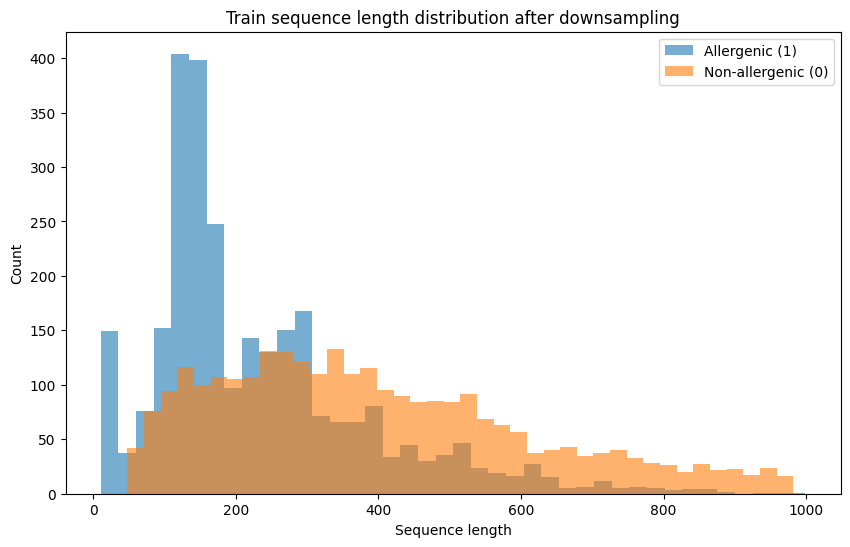

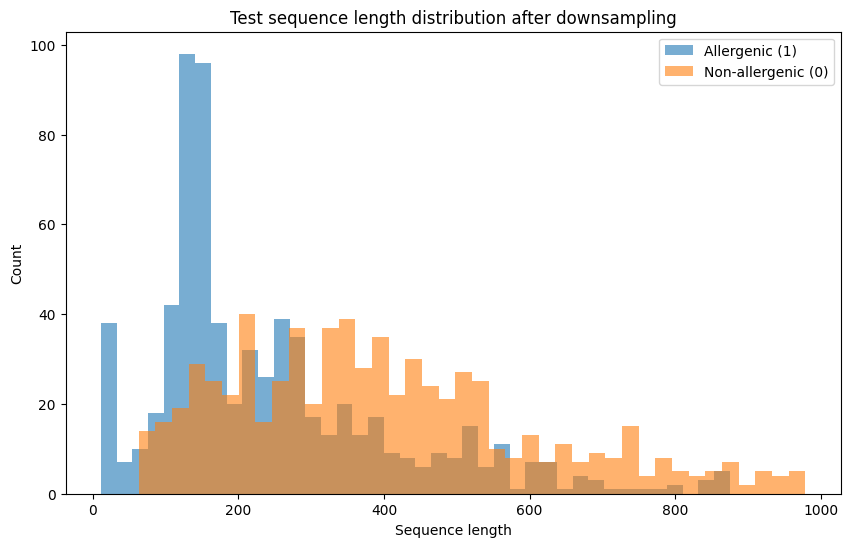

In [6]:
balanced_split_dfs = {}

for split_name, split_df in cleaned_split_dfs.items():
    class_counts = split_df["label"].value_counts().sort_index()
    target_count = int(class_counts.min())
    balanced_split_dfs[split_name] = pd.concat(
        [
            split_df.loc[split_df["label"] == 1].sample(n=target_count, random_state=42),
            split_df.loc[split_df["label"] == 0].sample(n=target_count, random_state=42),
        ],
        ignore_index=True,
    ).sample(frac=1, random_state=42).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        balanced_split_dfs[split_name].loc[balanced_split_dfs[split_name]["label"] == 1, "sequence"].str.len(),
        bins=40,
        alpha=0.6,
        label="Allergenic (1)",
    )
    ax.hist(
        balanced_split_dfs[split_name].loc[balanced_split_dfs[split_name]["label"] == 0, "sequence"].str.len(),
        bins=40,
        alpha=0.6,
        label="Non-allergenic (0)",
    )
    ax.set_title(f"{split_name.capitalize()} sequence length distribution after downsampling")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()


In [7]:
for split_name, split_df in balanced_split_dfs.items():
    output_path = SPLIT_OUTPUT_PATHS[split_name]
    split_df.to_csv(output_path, index=False)
    final_counts = split_df["label"].value_counts().sort_index()
    print(f"Saved {split_name} cleaned dataset to: {output_path}")
    print(final_counts.rename(index={0: "non-allergenic", 1: "allergenic"}).to_string())
    print()


Saved train cleaned dataset to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/deepalgpro_train_cleaned.csv
label
non-allergenic    2784
allergenic        2784

Saved test cleaned dataset to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/deepalgpro_test_cleaned.csv
label
non-allergenic    688
allergenic        688



In [9]:
for split in ["train", "test"]:
    df = balanced_split_dfs[split]
    counts = df["label"].value_counts().to_dict()
    
    print(f"\n=== {split.upper()} FINAL DATASET ===")
    print(f"Total sequences: {len(df):,}")
    print(f"Class distribution: {counts}")


=== TRAIN FINAL DATASET ===
Total sequences: 5,568
Class distribution: {1: 2784, 0: 2784}

=== TEST FINAL DATASET ===
Total sequences: 1,376
Class distribution: {1: 688, 0: 688}
